<a href="https://colab.research.google.com/github/andressonsino/perceptron-simple/blob/main/peceptron_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller Práctico: Clasificación de Riesgo Crediticio con Perceptrón
## Contexto del Problema
Una entidad financiera desea automatizar la aprobación de créditos pre-aprobados.

Se cuenta con dos variables de entrada:

* Puntaje Crediticio (Normalizado de 0 a 1).

* Ratio de Ahorro (Dinero ahorrado vs ingresos anuales).

El objetivo es entrenar un Perceptrón Simple en Keras para que aprenda la frontera de decisión que separa a los clientes de "Bajo Riesgo" (Clase 1) de los de "Alto Riesgo" (Clase 0).

## Paso 1: Preparación del Entorno
Cargamos las librerías necesarias y generamos un dataset sintético que represente este escenario.

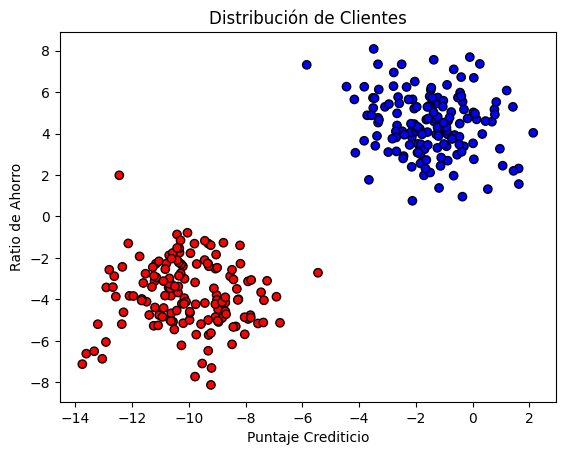

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs

# Generamos datos: 300 clientes con 2 características
X, y = make_blobs(n_samples=300, centers=2, n_features=2, cluster_std=1.5, random_state=1)

# Visualización inicial
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.xlabel("Puntaje Crediticio")
plt.ylabel("Ratio de Ahorro")
plt.title("Distribución de Clientes")
plt.show()

## Paso 2: Definición de la Arquitectura (Misión del Alumno)
Debes definir un modelo secuencial que represente un Perceptrón Simple. Recuerda que para una clasificación binaria, la salida debe pasar por una función que comprima el valor entre 0 y 1.

**Guía Técnica:**

* Usa una capa Dense.

* Como es un Perceptrón de una sola capa, units debe ser igual a 1.

* El input_shape debe coincidir con la cantidad de variables de entrada (2).

In [ ]:
model = Sequential()
model.add(Dense(units=1, input_shape=(2,), activation='sigmoid'))

## Paso 3: Compilación del Sistema
Para que el modelo aprenda, debemos definir el Optimizador (que gestiona la Tasa de Aprendizaje) y la Función de Pérdida (que mide el error).

**Ayuda Sugerida:**

* Para clasificación binaria, la pérdida estándar es binary_crossentropy.

* Experimenta con diferentes valores en learning_rate (prueba con 0.01, 0.1 y 0.5).

*Learning rate:* es la velocidad a la que el modelo ajusta sus pesos cuando comete un error.

In [ ]:
# Compilo el modelo
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Paso 4: Entrenamiento y Regularización
Es momento de ajustar los pesos. Vamos a entrenar el modelo, pero esta vez, presta atención a cómo el número de épocas afecta el resultado.

**Instrucciones:**

* Ejecuta el método .fit().

* Prueba configurar el entrenamiento con 50 épocas.

In [ ]:
# Entrenamiento del modelo con 50 épocas
history = model.fit(X, y, epochs=50, validation_split=0.2, verbose=1)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5458 - loss: 1.9605 - val_accuracy: 1.0000 - val_loss: 0.0876
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9958 - loss: 0.0919 - val_accuracy: 1.0000 - val_loss: 0.0387
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0538 - val_accuracy: 1.0000 - val_loss: 0.0252
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0402 - val_accuracy: 1.0000 - val_loss: 0.0186
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0330 - val_accuracy: 1.0000 - val_loss: 0.0148
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0282 - val_accuracy: 1.0000 - val_loss: 0.0122
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0250 - val_accuracy: 1.0000 - val_loss: 0.0104
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0225 - val_accuracy: 1.0000 - val_loss: 0.0090
Epoch 9

## Experimentación con Learning Rate

Se entrenó el modelo con 50 épocas y se probaron tres valores de tasa de aprendizaje.

### Learning Rate = 0.01
- Loss:  0.0296
- Accuracy: 1.0000 (100%)
- Val_loss: 0.0139
- Val_accuracy: 1.0000 (100%)

### Learning Rate = 0.1
- Loss: 0.0068
- Accuracy: 1.0000 (100%)
- Val_loss: 0.0012
- Val_accuracy: 1.0000 (100%)

### Learning Rate = 0.5
- Loss: 0.0028
- Accuracy: 1.0000 (100%)
- Val_loss: 0.0001
- Val_accuracy: 1.0000 (100%)

### Conclusión
- 0.01 — Aprendizaje lento. El loss bajó gradualmente durante las 50 épocas sin llegar a valores muy bajos.
- 0.1 — Aprendizaje más estable y eficiente. Buen equilibrio entre velocidad y precisión.
- 0.5 — Aprendizaje muy rápido. Alcanzó el loss más bajo, funcionó bien porque los datos son simples y separables.

## Paso 5: Evaluación de Resultados
Una vez entrenado, utilizaremos el siguiente bloque para visualizar la Frontera de Decisión que tu modelo ha construido.

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 1s 648us/step


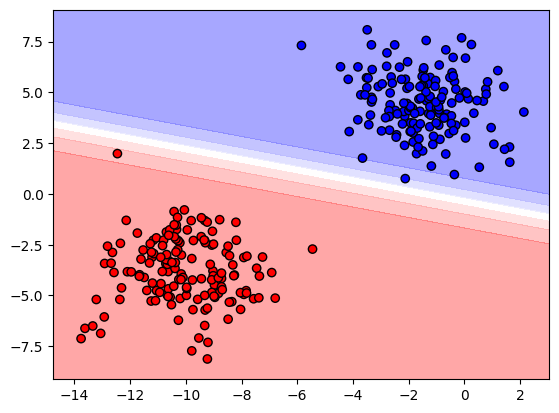

In [ ]:
def plot_frontier(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.show()

plot_frontier(X, y, model)

## Desafíos Extra
**Impacto del Sesgo:** Si imprimes los pesos del modelo con model.get_weights(), ¿cuál es el valor del Bias?

¿Qué pasaría si fuera cero?


- Pesos: [-0.4431, -1.9462] → uno por cada variable de entrada
- Bias: -0.0307 → un valor extra que no depende de ninguna variable

### ¿Qué es el Bias?
Es un valor que le permite al modelo desplazar la frontera de decisión
hacia donde están los datos. Sin él, la línea separadora estaría
obligada a pasar por el punto (0,0) del gráfico, sin importar dónde
estén ubicadas las nubes de puntos.

### ¿Qué pasaría si fuera cero?
La frontera quedaría mal ubicada porque las dos nubes de puntos
no están centradas en el origen. El modelo necesita ese ajuste
para poder separar correctamente los datos.


**Regularización:** Regresa al Paso 2 e intenta agregar kernel_regularizer='l2' dentro de la capa Dense.

¿Notas algún cambio en la suavidad de la frontera o en el valor de los pesos?


Se agregó kernel_regularizer='l2' a la capa Dense y se reentrenó el modelo.

### Cambios en los pesos:
- Sin L2: [-0.4431, -1.9462]
- Con L2: [-0.3238, -1.2150]
Los pesos son más pequeños porque L2 penaliza valores grandes
durante el entrenamiento, obligando al modelo a no depender
demasiado de ninguna variable.

### Cambio en la frontera:
La frontera de decisión se ve más suave y con una zona de
transición más amplia (la franja entre el rojo y el azul
es más gradual).

### ¿Para qué sirve L2?
Sin regularización el modelo puede ajustar los pesos a valores
muy grandes para acertar mejor en los datos de entrenamiento,
pero luego fallar con datos nuevos. L2 actúa como un freno que
mantiene los pesos controlados, mejorando la capacidad del modelo
de generalizar.


**No Linealidad:** Cambia el generador de datos por make_moons(n_samples=300, noise=0.1).

¿Es capaz el Perceptrón de una sola capa de separar estos datos? Justifica basándote en la teoría de Separabilidad Lineal.

## Desafío 3: No Linealidad — make_moons

Se reemplazó make_blobs por make_moons(n_samples=300, noise=0.1),
que genera dos nubes de puntos en forma de medias lunas entrelazadas.

### Resultado:
- Accuracy entrenamiento: 85%
- Accuracy validación: 75%
- La frontera de decisión es una línea diagonal recta que
  claramente no logra separar las dos clases.

### ¿Por qué falla el perceptrón simple?
Esto se conoce como el problema de No Separabilidad Lineal:
El perceptrón simple solo puede trazar líneas rectas como
frontera de decisión. Los datos en forma de media luna
requieren una curva para separarse correctamente — algo
que una línea recta nunca puede lograr sin importar cuánto
se entrene el modelo.

### ¿Cuál sería la solución?
Una red neuronal multicapa (MLP), que agrega capas ocultas
capaces de aprender fronteras curvas y complejas.